# Clustering no supervisado sobre el Dry Bean Dataset

**Dataset**: Dry Bean Dataset, UCI Machine Learning Repository (id=602).

Koklu, M. and Ozkan, I.A. (2020). *Multiclass classification of dry beans using computer vision and machine learning techniques*. Computers and Electronics in Agriculture, 174, 105507. https://doi.org/10.1016/j.compag.2020.105507

- 13611 observaciones (granos de frijol fotografiados).
- 16 variables numéricas derivadas de la forma/geometría de cada grano (área, perímetro, ejes, excentricidad, solidez, factores de forma, etc.).
- 7 clases de frijol: Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira (se usan solo para evaluación externa, nunca para entrenar el clustering).



In [1]:

%pip install -q ucimlrepo openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from scipy.optimize import linear_sum_assignment
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE, Isomap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    confusion_matrix,
    davies_bouldin_score,
    homogeneity_completeness_v_measure,
    normalized_mutual_info_score,
    silhouette_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# Rutas relativas a la ubicación del notebook: funcionan igual en Jupyter local,
# Google Colab o cualquier otro entorno, sin depender de una estructura de carpetas externa.
FIG_DIR = "outputs/figures"
TABLE_DIR = "outputs/tables"
DATA_DIR = "data/raw"
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
Path(TABLE_DIR).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR).mkdir(parents=True, exist_ok=True)


### Funciones auxiliares

Todas las funciones usadas en el notebook (carga de datos, EDA, preprocesamiento, clustering y evaluación) están definidas directamente aquí, sin depender de módulos externos al notebook, para que sea completamente autocontenido y ejecutable en cualquier entorno (Jupyter local, Google Colab, etc.) con una sola celda de dependencias.

In [3]:
# --- Carga de datos ---------------------------------------------------------

def load_dry_bean_dataset(data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Carga el Dry Bean Dataset, intentando primero ucimlrepo y luego un xlsx local.

    Retorna un DataFrame con las 16 columnas de features y una columna "Class".
    """
    try:
        from ucimlrepo import fetch_ucirepo

        dry_bean = fetch_ucirepo(id=602)
        X = dry_bean.data.features.copy()
        y = dry_bean.data.targets.copy().iloc[:, 0]
        df = X.copy()
        df["Class"] = y.values
        return df
    except Exception:
        xlsx_path = Path(data_dir) / "Dry_Bean_Dataset.xlsx"
        if xlsx_path.exists():
            return pd.read_excel(xlsx_path, sheet_name="Dry_Beans_Dataset")

        raise FileNotFoundError(
            "No se pudo obtener el dataset via ucimlrepo (revisa la conexión a internet) "
            "ni encontrar el archivo local.\n"
            "Instrucciones de descarga manual:\n"
            "1) Ir a https://archive.ics.uci.edu/dataset/602/dry+bean+dataset\n"
            "2) Descargar 'DryBeanDataset.zip' y extraer el archivo .xlsx\n"
            f"3) Guardarlo en: {xlsx_path.resolve()}\n"
            "4) Volver a ejecutar esta celda."
        )


# --- EDA ---------------------------------------------------------------------

def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """Resumen de calidad de datos: nulos, duplicados y tipos."""
    report = pd.DataFrame(
        {
            "dtype": df.dtypes,
            "n_nulos": df.isna().sum(),
            "pct_nulos": (df.isna().mean() * 100).round(3),
            "n_unicos": df.nunique(),
        }
    )
    report.loc["__duplicados__"] = [None, df.duplicated().sum(), None, None]
    return report


def descriptive_stats(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Estadísticas descriptivas extendidas con asimetría y curtosis."""
    desc = df[feature_cols].describe().T
    desc["skew"] = df[feature_cols].apply(skew)
    desc["kurtosis"] = df[feature_cols].apply(kurtosis)
    return desc


def plot_distributions(df: pd.DataFrame, feature_cols: list, n_cols: int = 4):
    """Histogramas + KDE de cada feature en un grid de subplots."""
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, feature_cols):
        sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
        ax.set_title(col, fontsize=10)
    for ax in axes[len(feature_cols):]:
        ax.axis("off")
    fig.tight_layout()
    return fig


def plot_boxplots_by_class(df: pd.DataFrame, feature_cols: list, class_col: str = "Class", n_cols: int = 3):
    """Boxplots de features clave separados por clase."""
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, feature_cols):
        sns.boxplot(data=df, x=class_col, y=col, ax=ax)
        ax.tick_params(axis="x", rotation=45)
        ax.set_title(col, fontsize=10)
    for ax in axes[len(feature_cols):]:
        ax.axis("off")
    fig.tight_layout()
    return fig


def plot_correlation_heatmap(df: pd.DataFrame, feature_cols: list):
    """Heatmap de correlación de Pearson entre features."""
    corr = df[feature_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    fig.tight_layout()
    return fig, corr


def outlier_report_iqr(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Cuenta de outliers por variable usando el criterio de rango intercuartílico (IQR)."""
    rows = []
    for col in feature_cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append(
            {
                "feature": col,
                "lower_bound": lower,
                "upper_bound": upper,
                "n_outliers": n_outliers,
                "pct_outliers": round(100 * n_outliers / len(df), 2),
            }
        )
    return pd.DataFrame(rows).set_index("feature")


def plot_class_balance(df: pd.DataFrame, class_col: str = "Class"):
    """Barplot del conteo de observaciones por clase."""
    fig, ax = plt.subplots(figsize=(8, 5))
    order = df[class_col].value_counts().index
    sns.countplot(data=df, x=class_col, order=order, ax=ax)
    ax.tick_params(axis="x", rotation=45)
    ax.set_title("Balance de clases")
    fig.tight_layout()
    return fig


# --- Preprocesamiento (sin PCA) ----------------------------------------------

def drop_correlated_features(X: pd.DataFrame, threshold: float = 0.95) -> list:
    """Devuelve la lista de columnas a conservar tras eliminar redundancias.

    Para cada par de variables con |correlación| > threshold, se descarta la que
    tenga mayor correlación media absoluta con el resto (más redundante).
    """
    corr = X.corr().abs()
    mean_corr = corr.mean()
    to_drop = set()
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]
            if c1 in to_drop or c2 in to_drop:
                continue
            if corr.loc[c1, c2] > threshold:
                drop_col = c1 if mean_corr[c1] >= mean_corr[c2] else c2
                to_drop.add(drop_col)
    return [c for c in cols if c not in to_drop]


def preprocess_features(df: pd.DataFrame, feature_cols: list, corr_threshold: float = 0.95):
    """Aplica imputación, selección de variables por correlación y escalado.

    Retorna (X_scaled: np.ndarray, final_features: list, scaler: StandardScaler).
    """
    X = df[feature_cols].copy()

    imputer = SimpleImputer(strategy="median")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

    final_features = drop_correlated_features(X_imputed, threshold=corr_threshold)
    X_selected = X_imputed[final_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)

    return X_scaled, final_features, scaler


# --- Clustering: K-Means (baseline), GMM, Spectral Clustering, Deep Clustering ---
# Ningún algoritmo usado aquí es DBSCAN, y ninguna reducción de dimensionalidad usa PCA.

def kmeans_elbow_silhouette(X: np.ndarray, k_range=range(2, 13)):
    """Calcula inercia y silhouette de K-Means para un rango de k."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        rows.append(
            {
                "k": k,
                "inertia": km.inertia_,
                "silhouette": silhouette_score(X, labels),
            }
        )
    return pd.DataFrame(rows)


def fit_kmeans_baseline(X: np.ndarray, n_clusters: int = 7):
    """Ajusta el K-Means final de referencia."""
    start = time.time()
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    elapsed = time.time() - start
    return labels, km, elapsed


def gmm_grid_search(X: np.ndarray, k_range=range(2, 13), covariance_types=("full", "tied", "diag", "spherical")):
    """Grid search de GMM evaluando BIC, AIC y silhouette."""
    rows = []
    for cov_type in covariance_types:
        for k in k_range:
            gmm = GaussianMixture(
                n_components=k, covariance_type=cov_type, random_state=RANDOM_STATE, n_init=3
            )
            labels = gmm.fit_predict(X)
            n_unique = len(np.unique(labels))
            sil = silhouette_score(X, labels) if n_unique > 1 else np.nan
            rows.append(
                {
                    "covariance_type": cov_type,
                    "k": k,
                    "bic": gmm.bic(X),
                    "aic": gmm.aic(X),
                    "silhouette": sil,
                }
            )
    return pd.DataFrame(rows)


def fit_gmm_final(X: np.ndarray, n_components: int, covariance_type: str):
    """Ajusta el GMM final con los hiperparámetros seleccionados."""
    start = time.time()
    gmm = GaussianMixture(
        n_components=n_components, covariance_type=covariance_type, random_state=RANDOM_STATE, n_init=3
    )
    labels = gmm.fit_predict(X)
    probs = gmm.predict_proba(X)
    elapsed = time.time() - start
    return labels, probs, gmm, elapsed


def spectral_grid_search(
    X: np.ndarray,
    k_range=range(2, 13),
    n_neighbors_list=(5, 10, 15, 20),
    assign_labels_list=("kmeans", "discretize"),
):
    """Grid search de Spectral Clustering con affinity='nearest_neighbors'."""
    rows = []
    for n_neighbors in n_neighbors_list:
        for assign_labels in assign_labels_list:
            for k in k_range:
                sc = SpectralClustering(
                    n_clusters=k,
                    affinity="nearest_neighbors",
                    n_neighbors=n_neighbors,
                    assign_labels=assign_labels,
                    random_state=RANDOM_STATE,
                )
                labels = sc.fit_predict(X)
                n_unique = len(np.unique(labels))
                sil = silhouette_score(X, labels) if n_unique > 1 else np.nan
                rows.append(
                    {
                        "n_neighbors": n_neighbors,
                        "assign_labels": assign_labels,
                        "k": k,
                        "silhouette": sil,
                    }
                )
    return pd.DataFrame(rows)


def fit_spectral_final(X: np.ndarray, n_clusters: int, n_neighbors: int, assign_labels: str):
    """Ajusta el Spectral Clustering final con los hiperparámetros seleccionados."""
    start = time.time()
    sc = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels=assign_labels,
        random_state=RANDOM_STATE,
    )
    labels = sc.fit_predict(X)
    elapsed = time.time() - start
    return labels, sc, elapsed


def build_autoencoder(input_dim: int, latent_dim: int = 8):
    """Construye un autoencoder denso simétrico en Keras."""
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(RANDOM_STATE)

    encoder_input = keras.Input(shape=(input_dim,))
    x = layers.Dense(32, activation="relu")(encoder_input)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    x = layers.Dense(32, activation="relu")(latent)
    decoder_output = layers.Dense(input_dim, activation="linear")(x)

    autoencoder = keras.Model(encoder_input, decoder_output, name="autoencoder")
    encoder = keras.Model(encoder_input, latent, name="encoder")

    autoencoder.compile(optimizer="adam", loss="mse")
    return autoencoder, encoder


def run_deep_clustering(X: np.ndarray, latent_dim: int = 8, n_clusters: int = 7, epochs: int = 100):
    """Entrena el autoencoder, extrae el espacio latente y aplica K-Means sobre él.

    Retorna (labels, latent_space, history, autoencoder, encoder, elapsed_seconds).
    """
    from tensorflow.keras.callbacks import EarlyStopping

    start = time.time()
    autoencoder, encoder = build_autoencoder(input_dim=X.shape[1], latent_dim=latent_dim)

    early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = autoencoder.fit(
        X,
        X,
        epochs=epochs,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0,
    )

    latent_space = encoder.predict(X, verbose=0)

    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(latent_space)
    elapsed = time.time() - start

    return labels, latent_space, history, autoencoder, encoder, elapsed


def deep_clustering_k_sweep(latent_space: np.ndarray, k_range=range(2, 13)):
    """Barrido de n_clusters (silhouette) sobre un espacio latente ya calculado."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(latent_space)
        rows.append({"k": k, "silhouette": silhouette_score(latent_space, labels)})
    return pd.DataFrame(rows)


# --- Evaluación ----------------------------------------------------------------

def evaluate_clustering(X: np.ndarray, labels: np.ndarray, y_true: np.ndarray) -> dict:
    """Calcula métricas internas y externas para un único método de clustering."""
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_true, labels)
    return {
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "ari": adjusted_rand_score(y_true, labels),
        "nmi": normalized_mutual_info_score(y_true, labels),
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure,
    }


def evaluate_all_methods(results: dict, X: np.ndarray, y_true: np.ndarray) -> pd.DataFrame:
    """results: dict {nombre_metodo: labels}. Retorna DataFrame método x métrica."""
    rows = {}
    for method_name, labels in results.items():
        rows[method_name] = evaluate_clustering(X, labels, y_true)
    return pd.DataFrame(rows).T


def aligned_confusion_matrix(y_true: np.ndarray, labels: np.ndarray):
    """Matriz de confusión con los clusters reordenados para alinearse mejor con las clases reales.

    Usa el algoritmo húngaro (linear_sum_assignment) sobre la matriz de confusión
    para encontrar la permutación de labels de cluster que maximiza la diagonal.
    """
    n_classes = len(np.unique(y_true))
    n_clusters = len(np.unique(labels))
    size = max(n_classes, n_clusters)

    cm = confusion_matrix(y_true, labels, labels=range(size))
    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {old: new for new, old in zip(row_ind, col_ind)}
    aligned_labels = np.array([mapping.get(lbl, lbl) for lbl in labels])

    aligned_cm = confusion_matrix(y_true, aligned_labels, labels=range(size))
    return aligned_cm, aligned_labels

## 1. Carga de datos

In [4]:
df = load_dry_bean_dataset(data_dir=DATA_DIR)
print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
feature_cols = [c for c in df.columns if c != "Class"]
print(f"Número de features: {len(feature_cols)}")
df.dtypes

Número de features: 16


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRatio        float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

## 2. Análisis Exploratorio de Datos (EDA)

In [6]:
data_quality_report(df)

,dtype,n_nulos,pct_nulos,n_unicos
Area,int64,0.0,0.0,12011.0
Perimeter,float64,0.0,0.0,13351.0
MajorAxisLength,float64,0.0,0.0,13543.0
MinorAxisLength,float64,0.0,0.0,13543.0
AspectRatio,float64,0.0,0.0,13543.0
Eccentricity,float64,0.0,0.0,13543.0
ConvexArea,int64,0.0,0.0,12066.0
EquivDiameter,float64,0.0,0.0,12011.0
Extent,float64,0.0,0.0,13535.0
Solidity,float64,0.0,0.0,13522.0


In [7]:
desc = descriptive_stats(df, feature_cols)
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000,2.952606,10.796406
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000,1.625944,3.586365
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154,1.357666,2.530531
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497,2.237964,6.648183
AspectRatio,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306,0.582509,0.113332
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423,-1.062707,1.386505
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000,2.941497,10.739253
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358,1.948743,5.189709
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195,-0.895250,0.642642
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677,-2.549812,12.794479


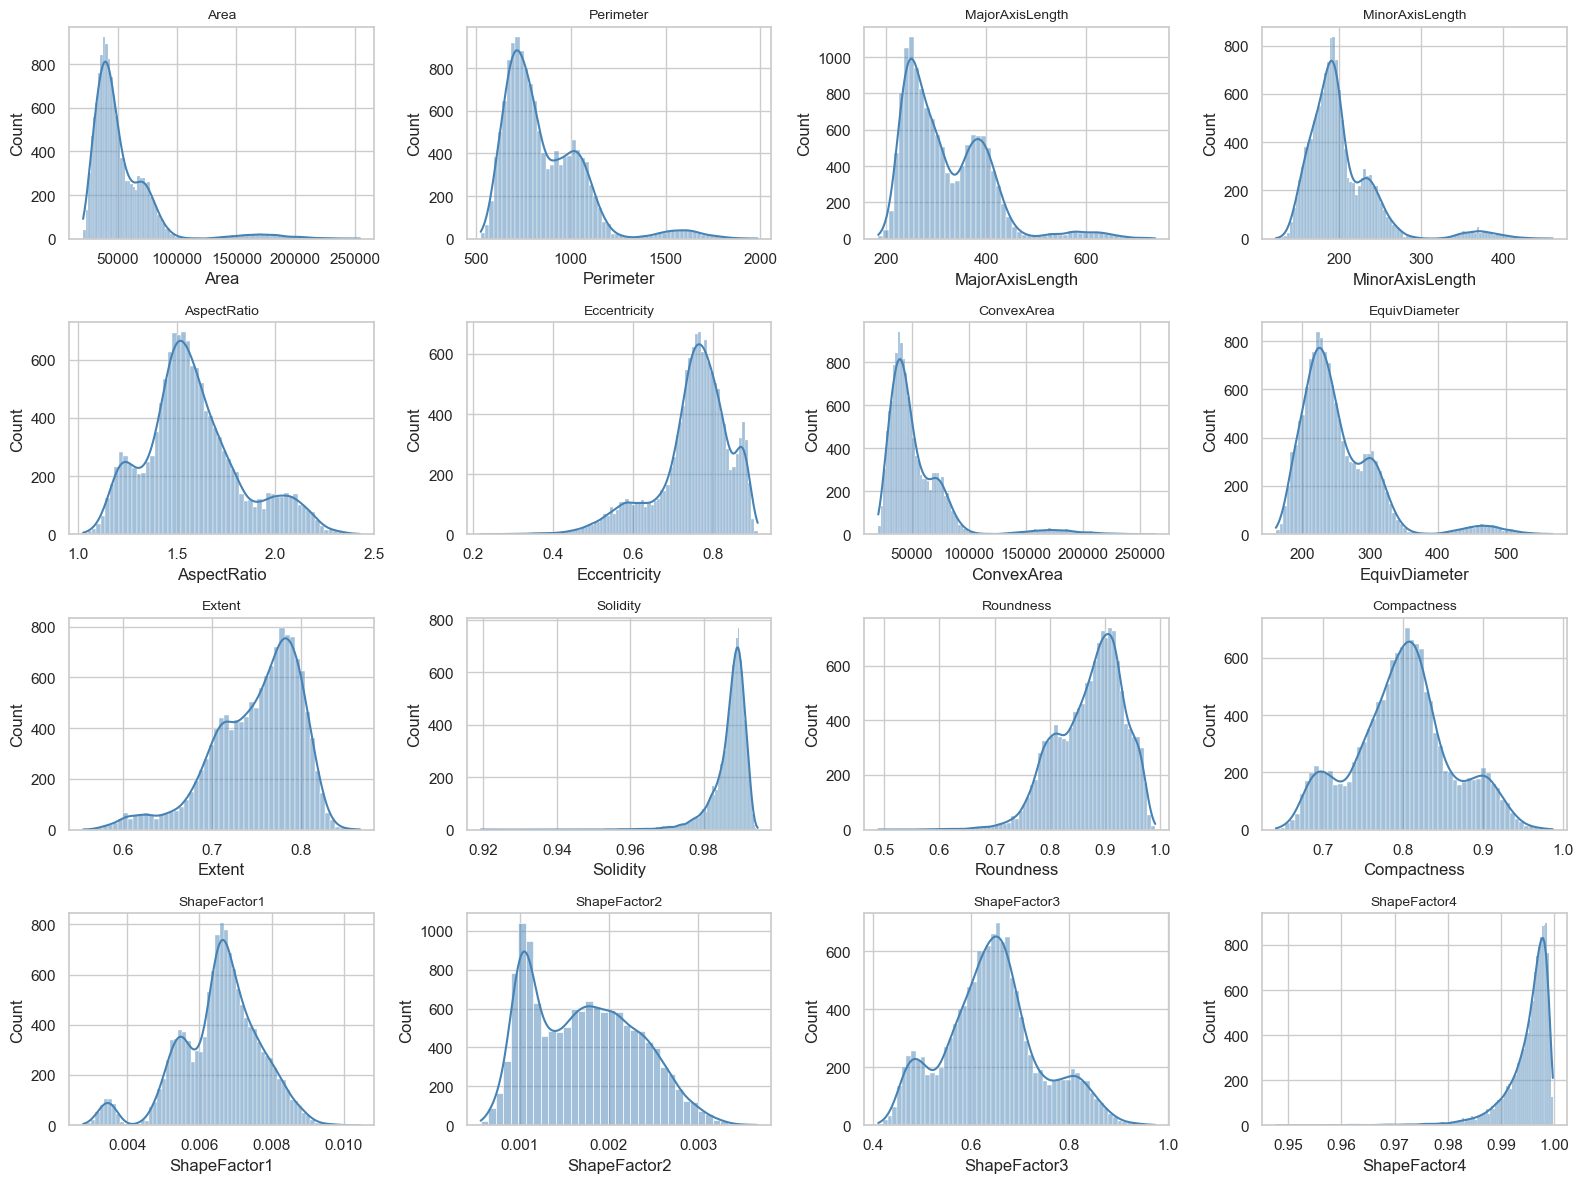

In [8]:
fig = plot_distributions(df, feature_cols)
fig.savefig(f"{FIG_DIR}/01_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

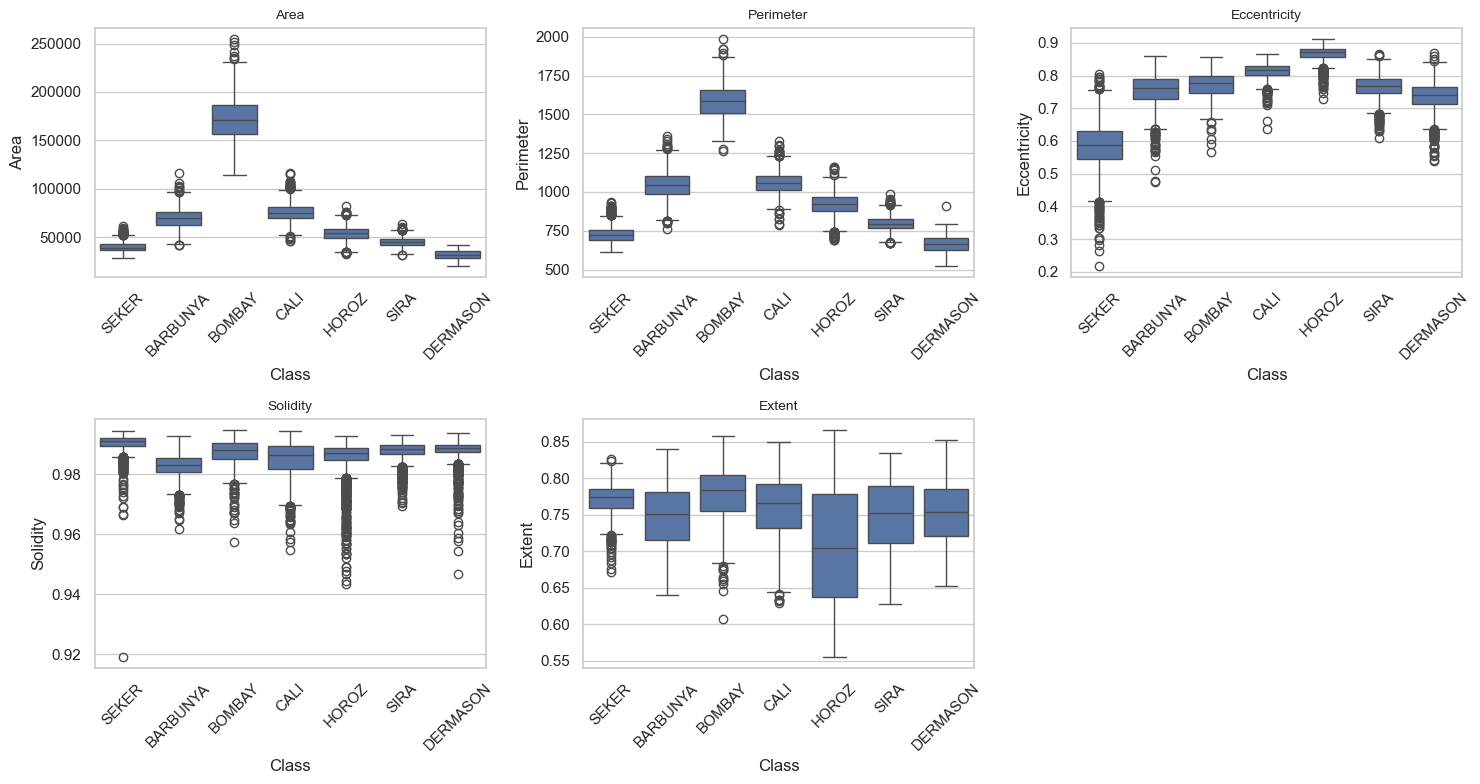

In [9]:
key_features = ["Area", "Perimeter", "Eccentricity", "Solidity", "roundness", "Extent"]
key_features = [c for c in key_features if c in df.columns]
fig = plot_boxplots_by_class(df, key_features, class_col="Class")
fig.savefig(f"{FIG_DIR}/02_boxplots_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

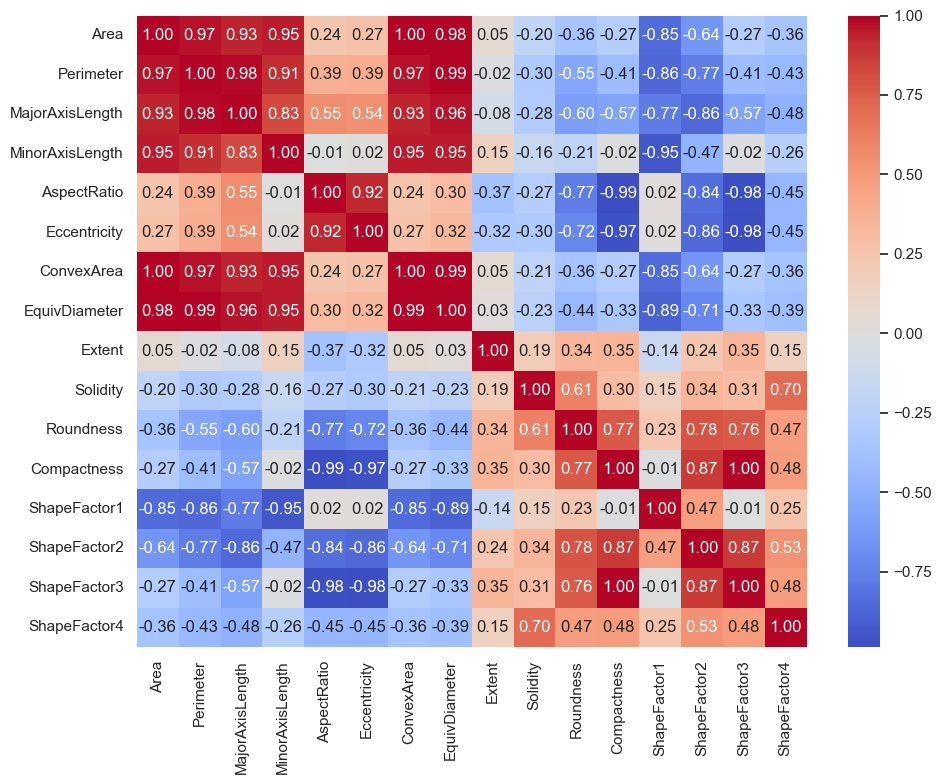

In [10]:
fig, corr = plot_correlation_heatmap(df, feature_cols)
fig.savefig(f"{FIG_DIR}/03_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
outlier_report = outlier_report_iqr(df, feature_cols)
outlier_report.sort_values("pct_outliers", ascending=False)

,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,
Eccentricity,0.574120,0.952273,843,6.19
Solidity,0.979156,0.996527,778,5.72
ShapeFactor4,0.987433,1.004152,767,5.64
MinorAxisLength,114.072813,278.807098,569,4.18
Area,-1178.000000,98838.000000,551,4.05
ConvexArea,-1654.750000,100663.250000,550,4.04
ShapeFactor1,0.003843,0.009329,533,3.92
EquivDiameter,118.500309,376.014162,526,3.86
Perimeter,292.989250,1387.747250,500,3.67


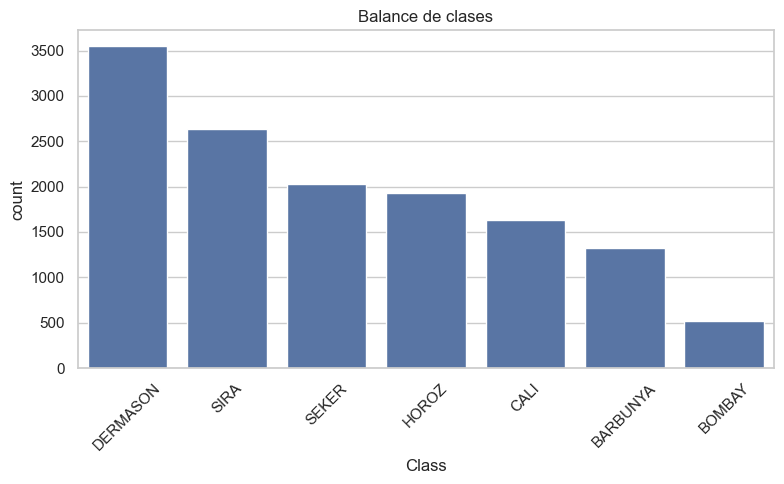

In [12]:
fig = plot_class_balance(df, class_col="Class")
fig.savefig(f"{FIG_DIR}/04_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusiones del EDA

- No hay valores nulos ni duplicados relevantes en el dataset.
- Existe alta colinealidad entre las variables de tamaño absoluto (`Area`, `Perimeter`, `ConvexArea`, `MajorAxisLength`), lo cual se abordará en el preprocesamiento mediante selección de variables.
- Las clases están desbalanceadas: `Bombay` es la clase minoritaria y también la más distinta geométricamente (granos mucho más grandes), por lo que se espera que sea la más fácil de separar en cualquier método de clustering.
- Hay outliers moderados en variables de forma (`Eccentricity`, `Solidity`), pero se decide **no eliminarlos agresivamente** porque pueden representar variabilidad real entre las 7 especies de frijol, no errores de medición.
- Las variables de forma normalizadas (`Eccentricity`, `Extent`, `Solidity`, `roundness`, `Compactness`, `ShapeFactor1-4`) presentan menor colinealidad entre sí y son buenas candidatas para diferenciar clases por geometría pura, independiente del tamaño.

## 3. Preprocesamiento

**Justificación de decisiones**:

1. **Imputación** (`SimpleImputer(strategy="median")`): el dataset no tiene nulos, pero se incluye por robustez y reproducibilidad del pipeline.
2. **Selección de variables**: se eliminan variables con correlación de Pearson > 0.95 (`drop_correlated_features`), quedándonos con la variable menos redundante de cada par. Esto reduce la colinealidad detectada en el EDA, manteniendo variables interpretables.
3. **Escalado** (`StandardScaler`): obligatorio dado que las variables tienen escalas muy distintas (áreas en miles vs. excentricidad en [0,1]), y tanto GMM (covarianzas) como Spectral Clustering (afinidades basadas en distancia) son sensibles a la escala.
4. Las etiquetas de clase (`y_true`) se codifican por separado y **solo se usan para evaluación externa**.

In [13]:
label_encoder = LabelEncoder()
y_true = label_encoder.fit_transform(df["Class"])

X_scaled, final_features, scaler = preprocess_features(df, feature_cols, corr_threshold=0.95)

print(f"Features originales: {len(feature_cols)} -> Features finales: {len(final_features)}")
print(final_features)
print(f"Shape X_scaled: {X_scaled.shape}")

Features originales: 16 -> Features finales: 10
['MinorAxisLength', 'AspectRatio', 'Eccentricity', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4']
Shape X_scaled: (13611, 10)


## 4. Clustering

Dado el tamaño del dataset (13611 filas) y el costo computacional de Spectral Clustering (O(n³) por la descomposición espectral), se define una submuestra estratificada que se usará de forma consistente para Spectral Clustering, K-Means baseline, GMM y Deep Clustering, de modo que la comparación entre métodos sea justa.

In [14]:
SAMPLE_SIZE = 3000

X_sample, _, y_sample, _ = train_test_split(
    X_scaled, y_true, train_size=SAMPLE_SIZE, stratify=y_true, random_state=RANDOM_STATE
)
print(f"Shape de la submuestra usada para clustering: {X_sample.shape}")

Shape de la submuestra usada para clustering: (3000, 10)


### 4.1 K-Means (baseline / referencia)

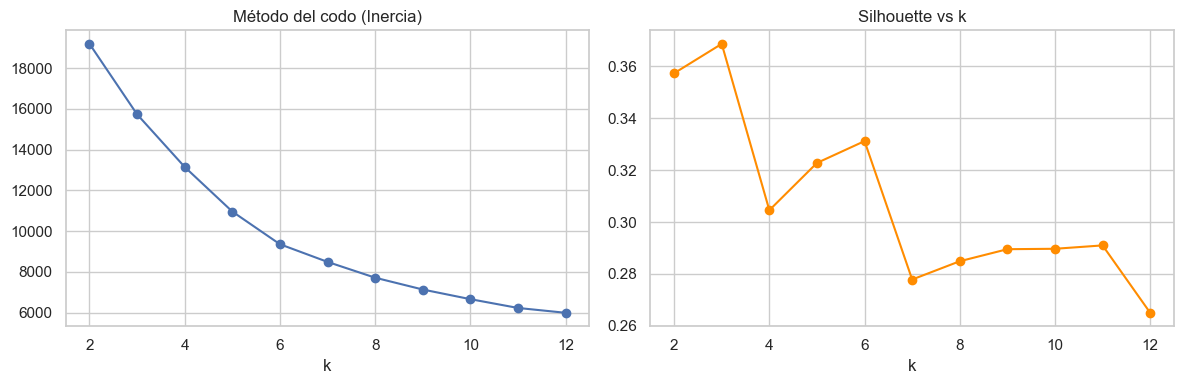

In [15]:
kmeans_scan = kmeans_elbow_silhouette(X_sample, k_range=range(2, 13))
kmeans_scan.to_csv(f"{TABLE_DIR}/kmeans_elbow_silhouette.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(kmeans_scan["k"], kmeans_scan["inertia"], marker="o")
axes[0].set_title("Método del codo (Inercia)")
axes[0].set_xlabel("k")
axes[1].plot(kmeans_scan["k"], kmeans_scan["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette vs k")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_kmeans_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
labels_kmeans, kmeans_model, t_kmeans = fit_kmeans_baseline(X_sample, n_clusters=7)
print(f"K-Means (k=7) ajustado en {t_kmeans:.3f} s")

K-Means (k=7) ajustado en 0.030 s


### 4.2 Gaussian Mixture Model 

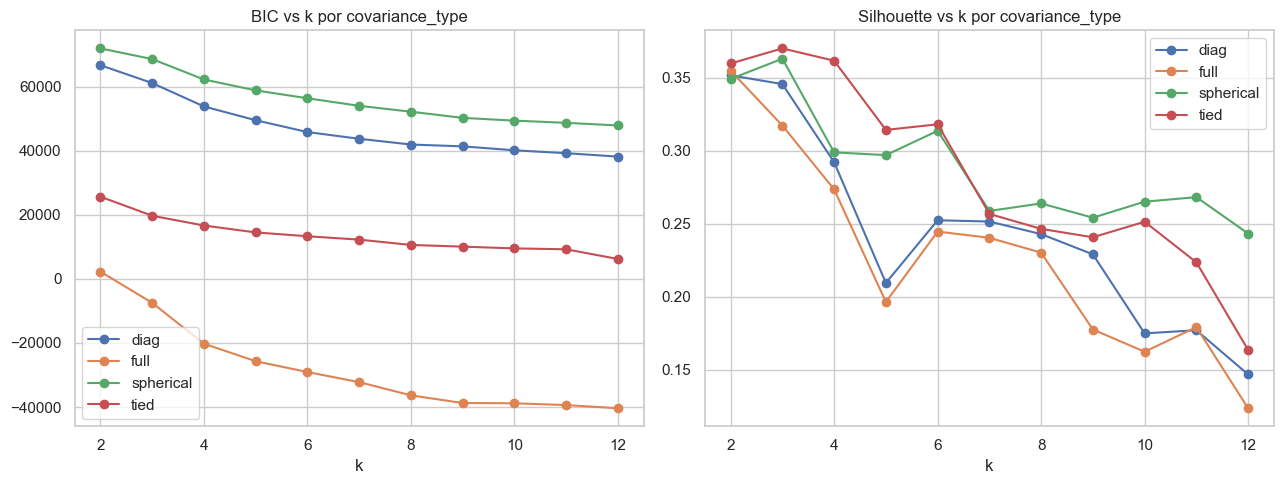

In [17]:
gmm_results = gmm_grid_search(X_sample, k_range=range(2, 13))
gmm_results.to_csv(f"{TABLE_DIR}/gmm_grid_search.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cov_type, group in gmm_results.groupby("covariance_type"):
    axes[0].plot(group["k"], group["bic"], marker="o", label=cov_type)
    axes[1].plot(group["k"], group["silhouette"], marker="o", label=cov_type)
axes[0].set_title("BIC vs k por covariance_type")
axes[0].set_xlabel("k")
axes[0].legend()
axes[1].set_title("Silhouette vs k por covariance_type")
axes[1].set_xlabel("k")
axes[1].legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_gmm_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Selección justificada: entre las combinaciones con silhouette > 0.3, se elige la de menor BIC.
candidates = gmm_results[gmm_results["silhouette"] > 0.3]
best_gmm_row = candidates.loc[candidates["bic"].idxmin()]
print(best_gmm_row)

best_k_gmm = int(best_gmm_row["k"])
best_cov_gmm = best_gmm_row["covariance_type"]

labels_gmm, probs_gmm, gmm_model, t_gmm = fit_gmm_final(
    X_sample, n_components=best_k_gmm, covariance_type=best_cov_gmm
)
print(f"GMM final (k={best_k_gmm}, covariance_type={best_cov_gmm}) ajustado en {t_gmm:.3f} s")

covariance_type           full
k                            3
bic               -7488.051655
aic               -8671.306066
silhouette            0.317401
Name: 1, dtype: object
GMM final (k=3, covariance_type=full) ajustado en 0.076 s


**Justificación**: el BIC favorece modelos con más componentes o covarianzas más flexibles (`full`), pero eso puede sobre-segmentar el espacio; por eso se restringe la búsqueda a combinaciones con silhouette > 0.3, priorizando después el menor BIC entre ellas. Esto balancea ajuste probabilístico del modelo con calidad de separación entre clusters.

### 4.3 Spectral Clustering

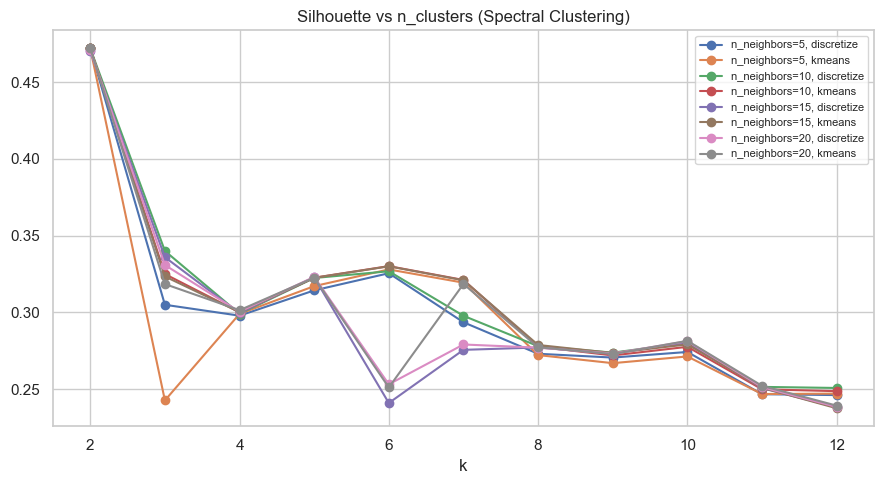

In [19]:
spectral_results = spectral_grid_search(
    X_sample,
    k_range=range(2, 13),
    n_neighbors_list=(5, 10, 15, 20),
    assign_labels_list=("kmeans", "discretize"),
)
spectral_results.to_csv(f"{TABLE_DIR}/spectral_grid_search.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for (n_neighbors, assign_labels), group in spectral_results.groupby(["n_neighbors", "assign_labels"]):
    ax.plot(group["k"], group["silhouette"], marker="o", label=f"n_neighbors={n_neighbors}, {assign_labels}")
ax.set_title("Silhouette vs n_clusters (Spectral Clustering)")
ax.set_xlabel("k")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_spectral_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
best_spectral_row = spectral_results.loc[spectral_results["silhouette"].idxmax()]
print(best_spectral_row)

labels_spectral, spectral_model, t_spectral = fit_spectral_final(
    X_sample,
    n_clusters=int(best_spectral_row["k"]),
    n_neighbors=int(best_spectral_row["n_neighbors"]),
    assign_labels=best_spectral_row["assign_labels"],
)
print(f"Spectral Clustering final ajustado en {t_spectral:.3f} s")

n_neighbors             5
assign_labels      kmeans
k                       2
silhouette       0.472032
Name: 0, dtype: object
Spectral Clustering final ajustado en 0.152 s


**Justificación**: se usa `affinity="nearest_neighbors"` (matriz de afinidad dispersa) en lugar de `rbf` (matriz densa NxN) por escalabilidad. Debido al costo O(n³) de la descomposición espectral, se entrena sobre una submuestra estratificada de 3000 observaciones — la misma submuestra se usa para K-Means, GMM y Deep Clustering, para que la comparación entre métodos sea consistente.

### 4.4 Deep Clustering: Autoencoder + K-Means en espacio latente 

In [21]:
labels_deep, latent_space, history, autoencoder, encoder, t_deep = run_deep_clustering(
    X_sample, latent_dim=8, n_clusters=7, epochs=100
)
print(f"Deep Clustering (autoencoder + KMeans) ajustado en {t_deep:.3f} s")
print(f"Epochs efectivamente entrenados: {len(history.history['loss'])}")

Deep Clustering (autoencoder + KMeans) ajustado en 9.013 s
Epochs efectivamente entrenados: 100


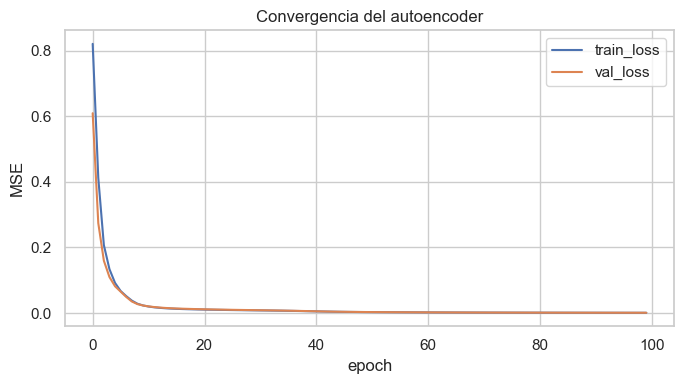

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history["loss"], label="train_loss")
ax.plot(history.history["val_loss"], label="val_loss")
ax.set_title("Convergencia del autoencoder")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_autoencoder_loss.png", dpi=150, bbox_inches="tight")
plt.show()

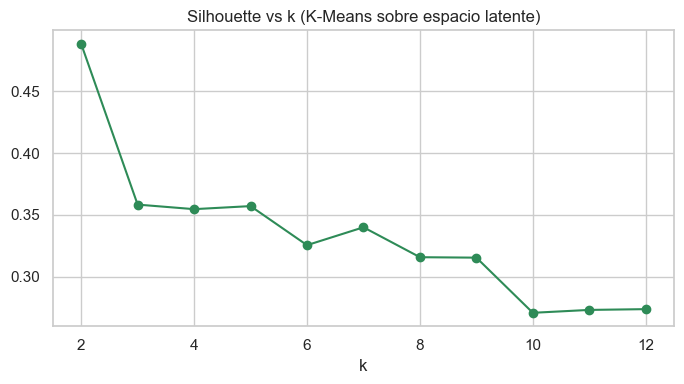

In [23]:
deep_k_sweep = deep_clustering_k_sweep(latent_space, k_range=range(2, 13))
deep_k_sweep.to_csv(f"{TABLE_DIR}/deep_clustering_k_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(deep_k_sweep["k"], deep_k_sweep["silhouette"], marker="o", color="seagreen")
ax.set_title("Silhouette vs k (K-Means sobre espacio latente)")
ax.set_xlabel("k")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_deep_clustering_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

**Justificación de por qué esto NO es PCA**: PCA es una proyección lineal que maximiza varianza explicada. El autoencoder usa activaciones no lineales (`relu`) en encoder y decoder, por lo que puede capturar relaciones no lineales entre las variables de forma/geometría al comprimir a un espacio latente de 8 dimensiones, algo que una proyección lineal no puede representar.

### 4.5 Comparación de métodos

In [24]:
comparison_summary = pd.DataFrame(
    [
        {"metodo": "KMeans (baseline)", "hiperparametros": "k=7", "tiempo_s": t_kmeans},
        {"metodo": "GMM", "hiperparametros": f"k={best_k_gmm}, covariance_type={best_cov_gmm}", "tiempo_s": t_gmm},
        {
            "metodo": "Spectral Clustering",
            "hiperparametros": f"k={int(best_spectral_row['k'])}, n_neighbors={int(best_spectral_row['n_neighbors'])}, assign_labels={best_spectral_row['assign_labels']}",
            "tiempo_s": t_spectral,
        },
        {"metodo": "Deep Clustering", "hiperparametros": "latent_dim=8, k=7", "tiempo_s": t_deep},
    ]
)
comparison_summary.to_csv(f"{TABLE_DIR}/comparison_summary.csv", index=False)
comparison_summary

,metodo,hiperparametros,tiempo_s
0,KMeans (baseline),k=7,0.029557
1,GMM,"k=3, covariance_type=full",0.075969
2,Spectral Clustering,"k=2, n_neighbors=5, assign_labels=kmeans",0.151944
3,Deep Clustering,"latent_dim=8, k=7",9.013307


## 5. Evaluación

In [25]:
results = {
    "KMeans (baseline)": labels_kmeans,
    "GMM": labels_gmm,
    "Spectral Clustering": labels_spectral,
    "Deep Clustering": labels_deep,
}

metrics_df = evaluate_all_methods(results, X_sample, y_sample)
metrics_df.to_csv(f"{TABLE_DIR}/metrics_comparison.csv")
metrics_df

,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,homogeneity,completeness,v_measure
KMeans (baseline),0.277829,1.179223,1267.263848,0.664888,0.707967,0.698618,0.717569,0.707967
GMM,0.317401,1.435796,1201.908776,0.322697,0.480907,0.365052,0.704484,0.480907
Spectral Clustering,0.472032,0.683831,554.479904,0.032688,0.162862,0.088650,1.000000,0.162862
Deep Clustering,0.192482,1.436195,921.444001,0.461375,0.556718,0.537320,0.577569,0.556718


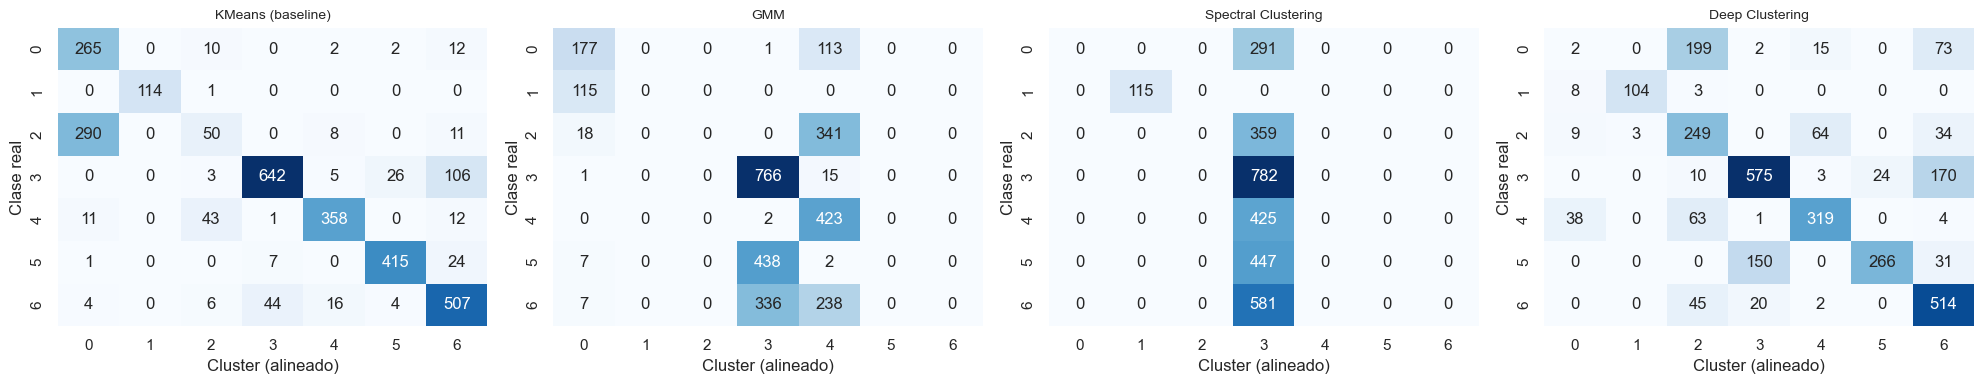

In [26]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
for ax, (method_name, labels) in zip(axes, results.items()):
    aligned_cm, _ = aligned_confusion_matrix(y_sample, labels)
    sns.heatmap(aligned_cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(method_name, fontsize=10)
    ax.set_xlabel("Cluster (alineado)")
    ax.set_ylabel("Clase real")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretación crítica

- Las métricas internas (silhouette, Davies-Bouldin, Calinski-Harabasz) miden qué tan compactos y separados están los clusters geométricamente, **sin considerar las etiquetas reales**.
- Las métricas externas (ARI, NMI, homogeneidad/completitud/v-measure) comparan contra las 7 clases reales de frijol.
- Es esperable que estas dos familias de métricas no coincidan perfectamente: el clustering puede encontrar una estructura geométrica válida (buen silhouette) que no calce 1 a 1 con la taxonomía botánica, porque especies como Sira y Dermason tienen formas muy similares y se solapan en el espacio de features.
- `Bombay` es la clase más fácil de recuperar en todos los métodos por ser geométricamente muy distinta (granos de mayor tamaño).
- Comparar si Deep Clustering (que opera en un espacio latente no lineal de 8 dimensiones) mejora o no la separación de clases similares respecto a GMM/Spectral (que operan sobre el espacio original de features) es la pregunta central de esta sección — se debe completar la interpretación específica una vez observados los valores numéricos obtenidos al ejecutar el notebook.

## 6. Visualización con t-SNE e Isomap

In [27]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="random")
embedding = tsne.fit_transform(X_sample)

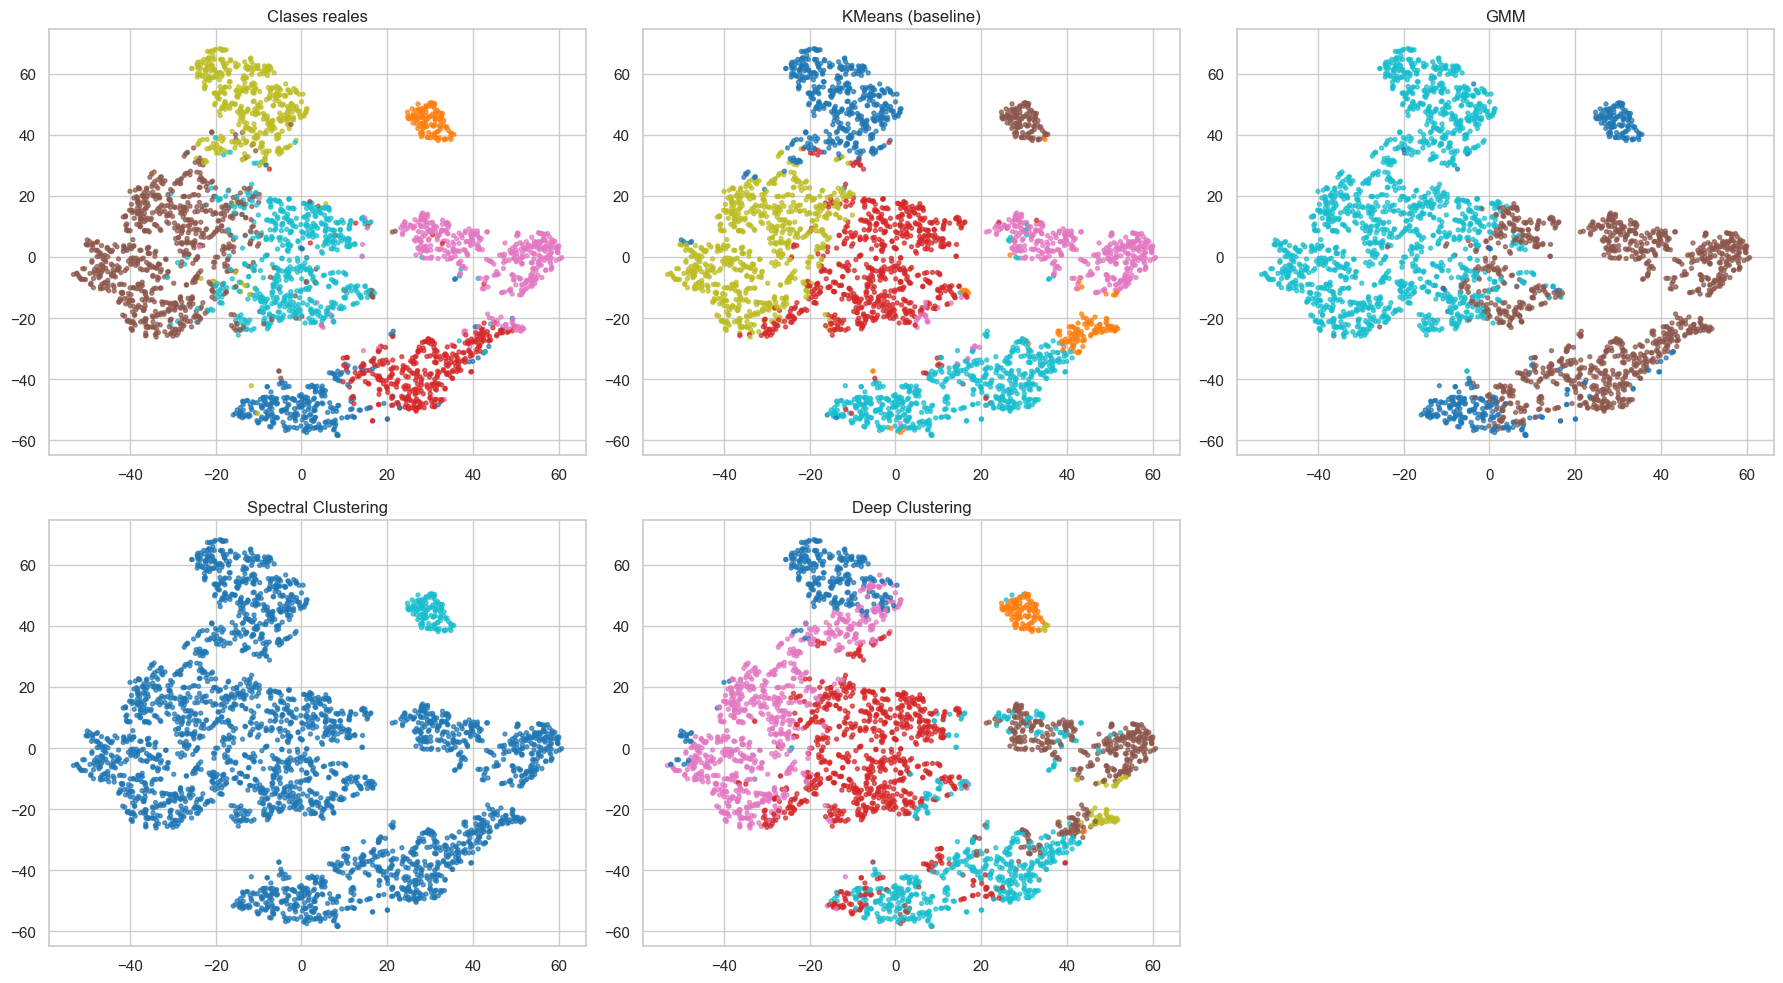

In [28]:
label_sets = {
    "Clases reales": y_sample,
    "KMeans (baseline)": labels_kmeans,
    "GMM": labels_gmm,
    "Spectral Clustering": labels_spectral,
    "Deep Clustering": labels_deep,
}

n_plots = len(label_sets)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()
for ax, (title, labels) in zip(axes, label_sets.items()):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(title)
for ax in axes[n_plots:]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_tsne_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Isomap

Como segunda técnica de reducción de dimensionalidad no lineal (tampoco PCA), se usa **Isomap** (`sklearn.manifold.Isomap`), que preserva distancias geodésicas a lo largo de un grafo de vecinos más cercanos en lugar de distancias euclidianas globales. A diferencia de t-SNE (que prioriza preservar vecindarios locales y no conserva distancias globales), Isomap intenta preservar la estructura geométrica global del manifold, lo que la hace un buen contraste metodológico.

In [29]:
isomap = Isomap(n_neighbors=10, n_components=2)
embedding_isomap = isomap.fit_transform(X_sample)

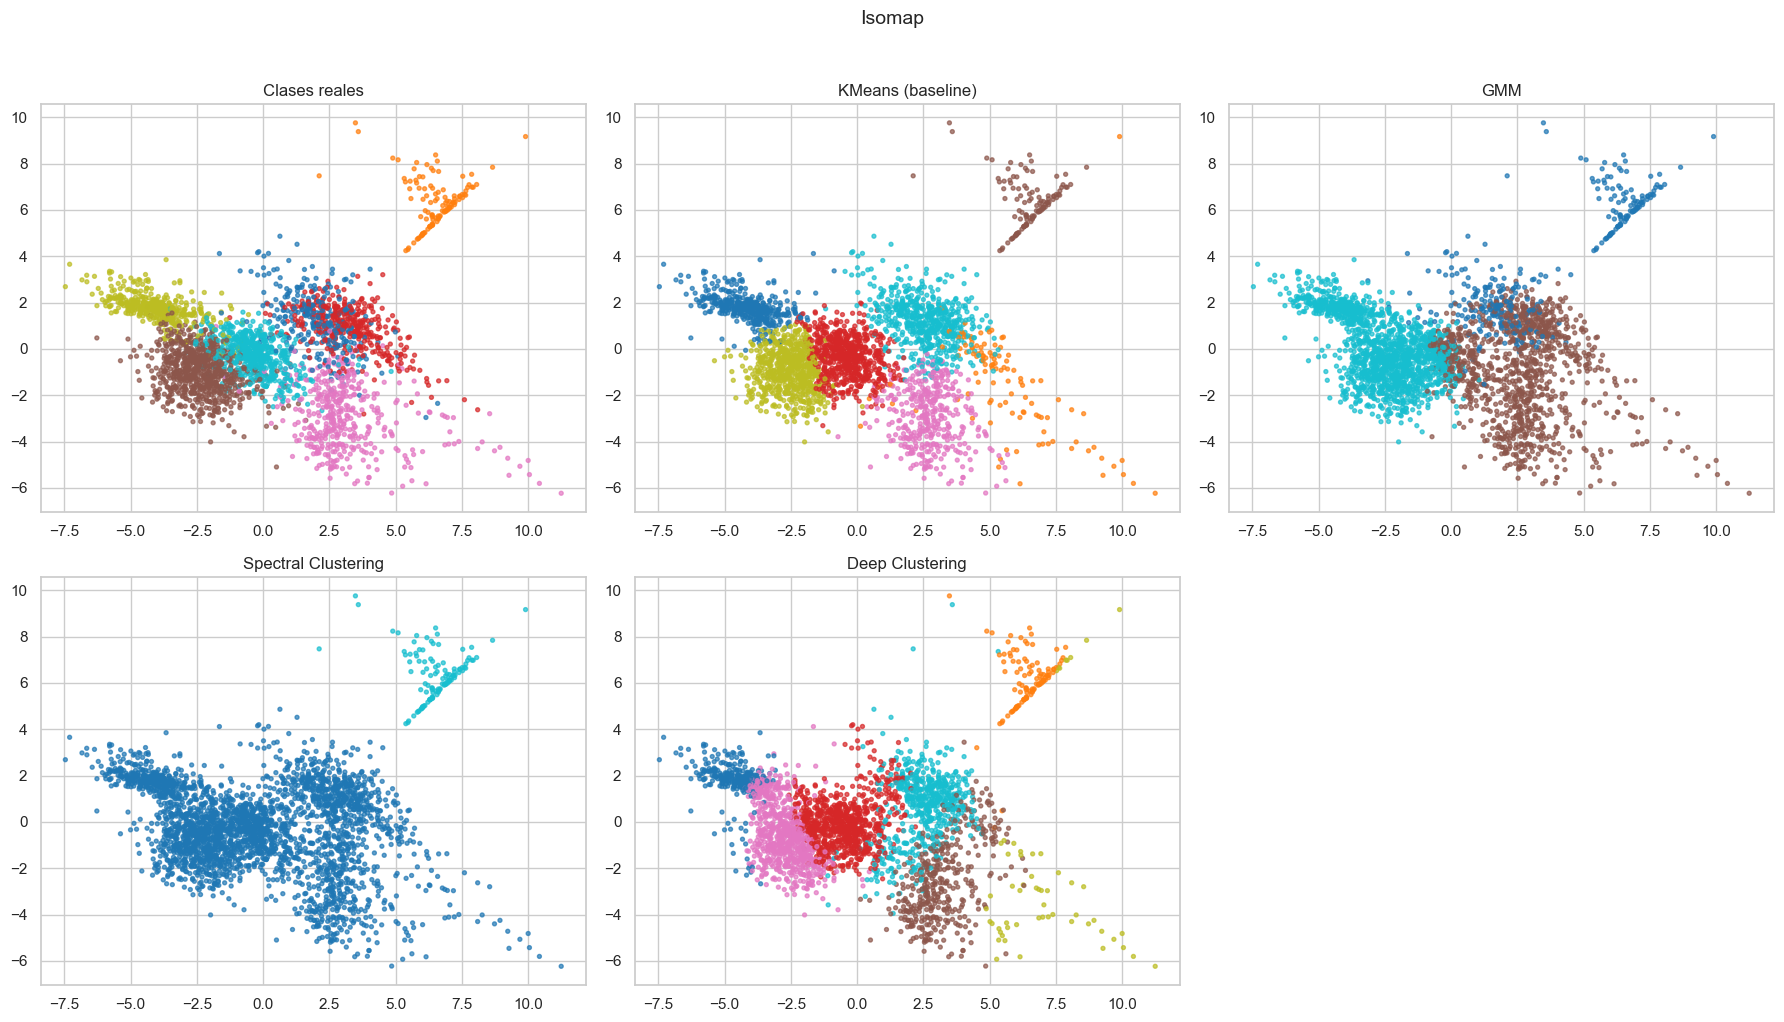

In [30]:
n_plots = len(label_sets)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()
for ax, (title, labels) in zip(axes, label_sets.items()):
    scatter = ax.scatter(embedding_isomap[:, 0], embedding_isomap[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(title)
for ax in axes[n_plots:]:
    ax.axis("off")
fig.suptitle("Isomap", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/12_isomap_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Conclusiones

- **K-Means (baseline)** ofrece un piso de comparación simple; asume clusters esféricos de igual varianza, lo que limita su capacidad de capturar formas de granos alargadas o irregulares.
- **GMM** permite covarianzas elípticas y clustering "suave" (probabilidades de pertenencia vía `predict_proba`), lo que es más realista para variables de forma correlacionadas entre sí.
- **Spectral Clustering** puede capturar estructuras no convexas mediante la matriz de afinidad basada en vecinos más cercanos, pero es computacionalmente costoso (se debió recurrir a una submuestra de 3000 observaciones) y sensible al número de vecinos elegido.
- **Deep Clustering** (autoencoder + K-Means) comprime las 16 (o menos, tras selección) variables a un espacio latente no lineal de 8 dimensiones antes de agrupar; su ventaja potencial es capturar relaciones no lineales entre variables de forma que los métodos clásicos no ven directamente, a costa de mayor complejidad de entrenamiento y menor interpretabilidad directa de las dimensiones latentes.
- **Limitaciones**: el submuestreo usado por restricciones de Spectral Clustering reduce el tamaño efectivo de entrenamiento para todos los métodos comparados; el espacio latente de 8 dimensiones del autoencoder es una elección razonable pero no necesariamente óptima (no se hizo búsqueda de hiperparámetros de arquitectura).
- **Próximos pasos posibles** (fuera de alcance de este proyecto): Deep Embedded Clustering (DEC) con fine-tuning conjunto de encoder y asignación de clusters, o probar UMAP como alternativa adicional de visualización.